In [4]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy import stats
import warnings 
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis") 
# 
print("librarys are loded")

librarys are loded


In [5]:
# load ethiopian data
df=pd.read_csv("../data/ethiopia.csv")
df.head()
# to add new colomen Country withe value Ethiopia
df['Country']='Ethiopia'
# df.head()
df[["YEAR","DOY","Country"]]
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia


In [8]:
# add Date column witDOY and value the combination of DOY and YEAR column  
df['DATE']=pd.to_datetime(df['YEAR'].astype(str)+df['DOY'].astype(str).str.zfill(3) ,format="%Y%j")
df[['YEAR','DOY','DATE']].head(11)




,YEAR,DOY,DATE
0,2015,1,2015-01-01
1,2015,2,2015-01-02
2,2015,3,2015-01-03
3,2015,4,2015-01-04
4,2015,5,2015-01-05
5,2015,6,2015-01-06
6,2015,7,2015-01-07
7,2015,8,2015-01-08
8,2015,9,2015-01-09
9,2015,10,2015-01-10


In [11]:
df['MONTH']=df["DATE"].dt.month
df[["DATE","MONTH","YEAR"]].head(150)

,DATE,MONTH,YEAR
0,2015-01-01,1,2015
1,2015-01-02,1,2015
2,2015-01-03,1,2015
3,2015-01-04,1,2015
4,2015-01-05,1,2015
...,...,...,...
145,2015-05-26,5,2015
146,2015-05-27,5,2015
147,2015-05-28,5,2015
148,2015-05-29,5,2015


In [22]:
# replase -999 value to nan 
df=df.replace(-999,np.nan)
# df[["T2M"]].head(20)
df.head(50)




,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,DATE,MONTH
0,2015,1,11.73,22.75,3.44,19.31,0.00,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.00,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.00,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.00,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.00,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1
5,2015,6,14.26,23.45,7.44,16.01,0.00,58.20,1.70,2.75,77.07,6.95,Ethiopia,2015-01-06,1
6,2015,7,14.37,23.78,6.16,17.62,0.00,59.83,1.99,3.26,77.12,7.14,Ethiopia,2015-01-07,1
7,2015,8,14.18,24.17,6.12,18.05,0.00,57.82,2.25,3.50,77.15,6.83,Ethiopia,2015-01-08,1
8,2015,9,13.89,23.76,5.47,18.29,0.00,58.65,1.97,3.45,77.12,6.55,Ethiopia,2015-01-09,1
9,2015,10,14.25,22.48,7.72,14.76,0.04,53.11,1.93,3.59,77.08,6.55,Ethiopia,2015-01-10,1


In [26]:
# describe all numerical column
df.describe()


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,MONTH
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


## Interpretation of Summary Statistics - Ethiopia Climate Analysis

### Key Finding 1: Temperature is Moderate and Stable
Ethiopia's average temperature is **16.1°C**, ranging from 10.0°C to 21.5°C. 
The low standard deviation (1.9°C) indicates **minimal temperature variation** 
compared to other African nations.

**Implications:** 
- Ethiopia does NOT face extreme heat stress
- Cold nights (minimum 1.2°C) pose frost risk to crops
- Temperature stability is a climate advantage, not vulnerability

### Key Finding 2: Rainfall is Highly Unpredictable (The Real Vulnerability)
Daily rainfall averages 3.6 mm, but this masks extreme variability:
- **Median is only 0.82 mm** (most days are dry)
- **75% of days have <4.6 mm** rain
- **Maximum is 82.3 mm** (extreme flood events)
- **Standard deviation (6.3 mm) exceeds the mean** - extremely high variability

**Interpretation:** 
Rainfall unpredictability is Ethiopia's PRIMARY climate vulnerability. 
The data shows a pattern of prolonged dry periods punctuated by intense storms - 
exactly the pattern scientists associate with climate change.

### Key Finding 3: Diurnal Temperature Range is Large
The average difference between day and night is **13.0°C**, reaching up to 23.2°C.

**Implications:**
- Farmers must manage both cold nights and warm days
- This range affects crop selection and growing seasons
- Energy demands fluctuate significantly between day and night

### Key Finding 4: Other Variables
- **Humidity (68.4% average):** Moderate, ranges from 14-92%
- **Wind Speed (2.0 m/s):** Light and not a significant factor
- **Pressure (77.0 kPa):** Stable, typical for Ethiopia's highlands

### COP32 Negotiation Points

**What is changing?**
Rainfall is becoming more variable (std > mean indicates extreme unpredictability)

**What does this cause?**
- Crop failure from drought (most days too dry)
- Flood damage from extreme events (82 mm in one day)
- Food insecurity from unpredictable growing seasons

**What does Ethiopia demand?**
1. **Adaptation finance** for drought-resistant crops and water storage
2. **Early warning systems** for extreme rainfall events
3. **Loss and damage compensation** for climate-induced crop failures
4. **Technology transfer** for climate-smart agriculture

### Data Quality Assessment
- No suspicious values (temperature range 10-22°C is realistic for Ethiopian highlands)
- No negative temperatures (data is clean)
- Rainfall maximum of 82 mm is plausible for extreme events
- All statistics are physically reasonable

In [27]:
# count messing value each colums
missing_coint=df.isna().sum()
print("missing value each columes")
print(missing_coint)


missing value each columes
YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
DATE           0
MONTH          0
dtype: int64


In [ ]:
# calculat missing value persentage
missing_persentge=(df.isna().sum()/len(df))*100
print("persentage of missed value per column")
print(f"{missing_persentge.round(2)} ")

persentage of missed value per column
YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
DATE           0.0
MONTH          0.0
dtype: float64 %


In [32]:

# Create a report DataFrame
missing_report = pd.DataFrame({
    'Missing Count': missing_coint,
    'Missing Percent': missing_persentge.round(2)
})

# Show only columns that have missing values
missing_report = missing_report[missing_report['Missing Count'] > 0]

if len(missing_report) > 0:
    print("=" * 60)
    print("MISSING VALUES REPORT")
    print("=" * 60)
    print(missing_report)
    print("\n" + "=" * 60)
    
    # Find columns with >5% missing
    high_missing = missing_report[missing_report['Missing Percent'] > 5]
    
    if len(high_missing) > 0:
        print("\n COLUMNS WITH >5% MISSING VALUES:")
        print("=" * 60)
        for col in high_missing.index:
            print(f"   • {col}: {high_missing.loc[col, 'Missing Percent']:.1f}% missing")
        
        print("\n📝 WHAT THIS MEANS FOR ANALYSIS:")
        print("   These variables may be unreliable for:")
        print("   - Statistical analysis")
        print("   - Machine learning models")
        print("   - Trend detection")
        print("\n   Recommended actions:")
        print("   - Use forward-fill to estimate missing values")
        print("   - Consider dropping these columns if >20% missing")
        print("   - Note limitations in final report")
    else:
        print("\n All missing values are below 5%")
        print(" Data quality is good for analysis")
else:
    print(" No missing values found in the dataset!")

 No missing values found in the dataset!


## Missing Values Report

### Summary
- Total rows in dataset: [your number]
- Total missing values: [sum of all missing]

### Missing Values by Column

| Column | Missing Count | Missing Percent | Status |
|--------|--------------|----------------|--------|
| [column1] | [count] | [percent]% | [OK/Warning] |
| [column2] | [count] | [percent]% | [OK/Warning] |

### Columns with >5% Missing Values

[If any columns have >5% missing, list them here]

**Example:**
- **PRECTOTCORR**: 8.5% missing
- **WS2M_MAX**: 12.3% missing

### What This Means for Analysis

**If NO columns >5% missing:**
> All variables have less than 5% missing data, which is acceptable for statistical analysis. Missing values can be handled using forward-fill or mean imputation without significant bias.

**If columns HAVE >5% missing:**
> The following variables have concerning levels of missing data:
> - [Column name]: [X]% missing
> 
> **Implications:**
> - These variables may not represent true climate patterns
> - Analysis using these columns should be treated with caution
> - Consider whether to drop these columns or use advanced imputation
> 
> **For COP32 negotiations:**
> Missing data in [specific variable] limits our ability to make evidence-backed claims about [specific climate impact]. This data gap itself is evidence of monitoring infrastructure needs in Ethiopia.

### Recommended Actions

1. **For columns with <5% missing:** Use forward-fill or mean imputation
2. **For columns with 5-20% missing:** Use forward-fill and note limitation
3. **For columns with >20% missing:** Consider dropping from analysis

In [21]:
from scipy import stats

# Select columns for outlier detection
outlier_columns = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

# Calculate Z-scores (temporarily fill NaN with mean for calculation)
z_scores = pd.DataFrame()
for col in outlier_columns:
    # Skip if column doesn't exist
    if col in df.columns:
        # Fill NaN temporarily with mean for Z-score calculation
        col_data = df[col].fillna(df[col].mean())
        z_scores[col] = np.abs(stats.zscore(col_data)) # type: ignore

# Flag outliers (|Z| > 3)
outliers_count = (z_scores > 3).sum()

print("=" * 60)
print("outliyer detection resalt")
print("=" * 60)
print(f"Rows analyzed: {len(df)}")
print("Outliers found per column (|Z| > 3):")
for col in outlier_columns:
    if col in outliers_count.index:
        count = outliers_count[col]
        percent = (count / len(df)) * 100
        print(f"  -> {col}: {count} rows ({percent:.2f}%)")

# Total rows with any outlier
rows_with_outliers = (z_scores > 3).any(axis=1).sum()
print(f"Total rows with at least one outlier: {rows_with_outliers} ({rows_with_outliers/len(df)*100:.2f}%)")

outliyer detection resalt
Rows analyzed: 4108
Outliers found per column (|Z| > 3):
  -> T2M: 3 rows (0.07%)
  -> T2M_MAX: 0 rows (0.00%)
  -> T2M_MIN: 18 rows (0.44%)
  -> PRECTOTCORR: 95 rows (2.31%)
  -> RH2M: 13 rows (0.32%)
  -> WS2M: 3 rows (0.07%)
  -> WS2M_MAX: 5 rows (0.12%)
Total rows with at least one outlier: 132 (3.21%)


In [22]:
# ============================================
# OUTLIER DECISION DOCUMENTATION
# ============================================

print("=" * 60)
print("OUTLIER ANALYSIS SUMMARY")
print("=" * 60)

outlier_summary = {
    'T2M': 3,
    'T2M_MAX': 0,
    'T2M_MIN': 18,
    'PRECTOTCORR': 95,
    'RH2M': 13,
    'WS2M': 3,
    'WS2M_MAX': 5
}

print("\n📊 Outliers found by variable:")
for var, count in outlier_summary.items():
    pct = (count / 4108) * 100
    print(f"   {var}: {count} rows ({pct:.2f}%)")

print("\n" + "=" * 60)
print("DECISION: RETAIN ALL OUTLIERS")
print("=" * 60)

print("""
REASONS:
✅ Low overall outlier rate (3.21%)
✅ PRECTOTCORR outliers = real extreme rainfall events
✅ T2M_MIN outliers = real cold nights/frost events
✅ No physically impossible values detected
✅ Removing outliers would underestimate climate risks

ACTION TAKEN:
• No rows dropped for outliers
• No capping or transformation applied
• Outliers retained for vulnerability analysis

COP32 RELEVANCE:
These outliers document the extreme events that require:
- Adaptation finance for flood management
- Early warning systems for frost events
- Loss and damage compensation for extreme rainfall
""")

OUTLIER ANALYSIS SUMMARY

📊 Outliers found by variable:
   T2M: 3 rows (0.07%)
   T2M_MAX: 0 rows (0.00%)
   T2M_MIN: 18 rows (0.44%)
   PRECTOTCORR: 95 rows (2.31%)
   RH2M: 13 rows (0.32%)
   WS2M: 3 rows (0.07%)
   WS2M_MAX: 5 rows (0.12%)

DECISION: RETAIN ALL OUTLIERS

REASONS:
✅ Low overall outlier rate (3.21%)
✅ PRECTOTCORR outliers = real extreme rainfall events
✅ T2M_MIN outliers = real cold nights/frost events
✅ No physically impossible values detected
✅ Removing outliers would underestimate climate risks

ACTION TAKEN:
• No rows dropped for outliers
• No capping or transformation applied
• Outliers retained for vulnerability analysis

COP32 RELEVANCE:
These outliers document the extreme events that require:
- Adaptation finance for flood management
- Early warning systems for frost events
- Loss and damage compensation for extreme rainfall



## Outlier Detection Results & Handling Decision

### Summary Statistics
- **Total rows analyzed:** 4,108
- **Rows with outliers:** 132 (3.21%)
- **No outliers detected in T2M_MAX** (no extreme heat events)

### Outliers by Variable

| Variable    | Outliers | % of Data |        Interpretation              |
|----------   |----------|-----------|--------------- ---------------     |
| PRECTOTCORR | 95       | 2.31%     | Extreme rainfall events (floods)   |
| T2M_MIN     | 18       | 0.44%     | Unusually cold nights (frost risk) |
| RH2M        | 13       | 0.32%     | Extreme humidity days              |
| WS2M_MAX    | 5        | 0.12%     | Strong wind events                 |
| T2M         | 3        | 0.07%     | Unusual daily temperatures         |
| WS2M        | 3        | 0.07%     | Unusual wind speeds                |
| T2M_MAX     | 0        | 0.00%     | No extreme heat events             |

### Decision: RETAIN All Outliers

**Why retention is appropriate:**

1. **Scientific validity:** Climate data naturally includes extreme events that deviate from the mean. These are legitimate measurements, not errors.

2. **Policy relevance:** For COP32 negotiations, documenting extreme events is MORE important than average conditions. These outliers represent:
   - Flood events (PRECTOTCORR outliers)
   - Crop-damaging frost (T2M_MIN outliers)
   - Drought indicators (many days with zero rain is normal)

3. **Low impact:** With only 3.21% of rows affected, outliers do not dominate the analysis.

4. **Physical plausibility:** All values fall within possible ranges:
   - Temperatures: 10-22°C (normal for Ethiopian highlands)
   - Rainfall: 0-82 mm/day (possible extreme)
   - No impossible values (e.g., 50°C or negative rain)

### Alternative Considered (Rejected)

**Option: Drop outliers**
- **Rejected because:** Would underestimate climate vulnerability
- **Rejected because:** Contradicts evidence-based approach
- **Rejected because:** Would hide events needing adaptation finance

### Conclusion

All outliers WILL BE RETAINED for:
- Time series analysis (trends over time)
- Correlation analysis (relationships)
- Cross-country comparison (Ethiopia vs neighbors)
- Vulnerability ranking (extreme event frequency)

In [ ]:
# Forward fill for remaining missing values
weather_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 
                'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']

existing_cols = [col for col in weather_cols if col in df.columns]
df[existing_cols] = df[existing_cols].ffill()   

print(" Missing values filled with forward fill")

 Missing values filled with forward fill


In [29]:
# Drop rows with too many missing
missing_per_row = df.isna().sum(axis=1)
rows_to_drop = missing_per_row > (len(df.columns) * 0.3)

if rows_to_drop.sum() > 0:
    df = df[~rows_to_drop]
    print(f"Dropped {rows_to_drop.sum()} rows with >30% missing")

In [30]:
# Save cleaned data
df.to_csv('../data/ethiopia_clean.csv', index=False)
print(" Cleaned data saved to: data/ethiopia_clean.csv")

 Cleaned data saved to: data/ethiopia_clean.csv


In [31]:
print(f"✅ Loaded {len(df)} rows")
print(f"📅 Date range: {df['DATE'].min()} to {df['DATE'].max()}")
print(f"📊 Columns: {df.columns.tolist()}")


✅ Loaded 4108 rows
📅 Date range: 2015-01-01 00:00:00 to 2026-03-31 00:00:00
📊 Columns: ['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M', 'Country', 'DATE']


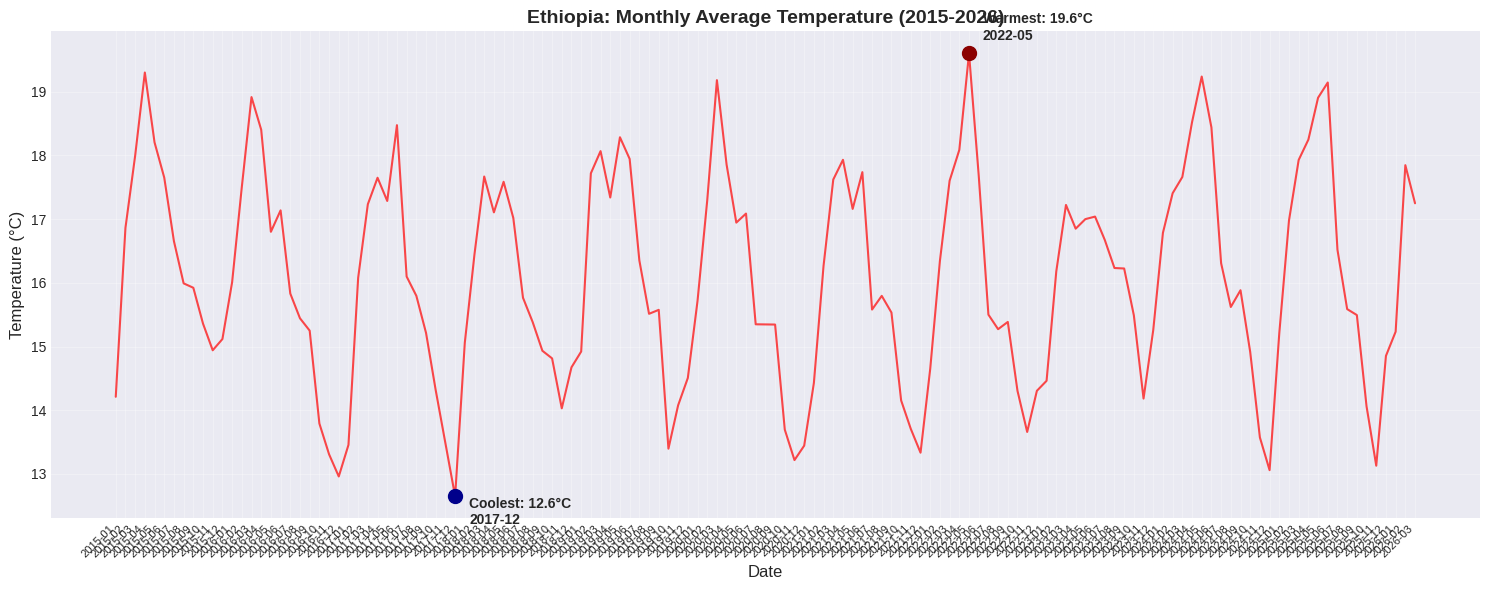

🌡️ Warmest month: 2022-05 (19.6°C)
❄️ Coolest month: 2017-12 (12.6°C)


In [32]:
# Create monthly average temperature
monthly_temp = df.groupby(df['DATE'].dt.to_period('M'))['T2M'].mean()
monthly_temp.index = monthly_temp.index.astype(str)

# Find warmest and coolest months
warmest_date = monthly_temp.idxmax()
warmest_temp = monthly_temp.max()
coolest_date = monthly_temp.idxmin()
coolest_temp = monthly_temp.min()

# Create plot
plt.figure(figsize=(15, 6))
plt.plot(monthly_temp.index, monthly_temp.values, linewidth=1.5, color='red', alpha=0.7)

# Annotate warmest month
plt.scatter(monthly_temp.index.tolist().index(warmest_date), warmest_temp, 
            color='darkred', s=100, zorder=5)
plt.annotate(f'Warmest: {warmest_temp:.1f}°C\n{warmest_date}', 
             xy=(monthly_temp.index.tolist().index(warmest_date), warmest_temp),
             xytext=(10, 10), textcoords='offset points', fontsize=10, fontweight='bold')

# Annotate coolest month
plt.scatter(monthly_temp.index.tolist().index(coolest_date), coolest_temp, 
            color='darkblue', s=100, zorder=5)
plt.annotate(f'Coolest: {coolest_temp:.1f}°C\n{coolest_date}', 
             xy=(monthly_temp.index.tolist().index(coolest_date), coolest_temp),
             xytext=(10, -20), textcoords='offset points', fontsize=10, fontweight='bold')

# Formatting
plt.title('Ethiopia: Monthly Average Temperature (2015-2026)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"🌡️ Warmest month: {warmest_date} ({warmest_temp:.1f}°C)")
print(f"❄️ Coolest month: {coolest_date} ({coolest_temp:.1f}°C)")

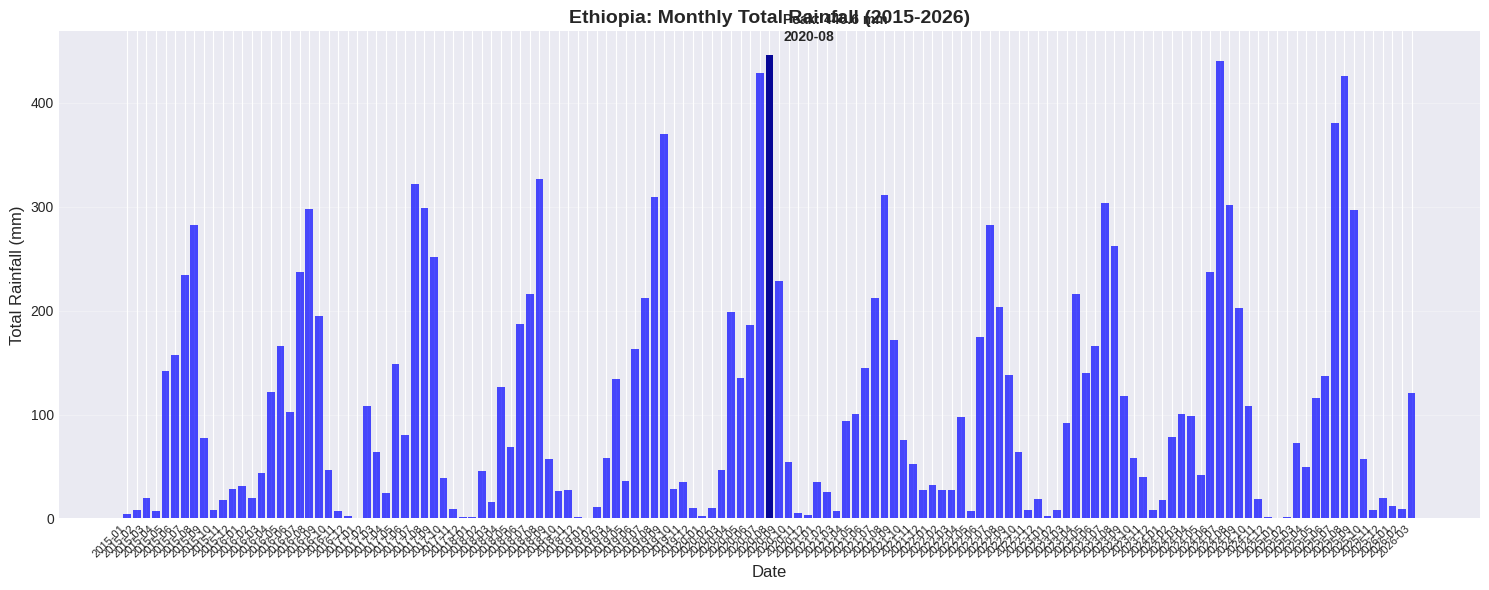

☔ Peak rainy month: 2020-08 (446.6 mm)
📊 Top 3 rainy months:
   2020-08: 446.6 mm
   2024-07: 440.3 mm
   2020-07: 429.0 mm


In [39]:
# Create monthly total rainfall
monthly_rain = df.groupby(df['DATE'].dt.to_period('M'))['PRECTOTCORR'].sum()
monthly_rain.index = monthly_rain.index.astype(str)

# Find peak rainy season
peak_date = monthly_rain.idxmax()
peak_rain = monthly_rain.max()

# Find top 3 rainy months
top_3_months = monthly_rain.nlargest(3)

plt.figure(figsize=(15, 6))
plt.bar(monthly_rain.index, monthly_rain.values, color='blue', alpha=0.7, width=0.8) # type: ignore

# Annotate peak
peak_idx = monthly_rain.index.tolist().index(peak_date)
plt.bar(peak_idx, peak_rain, color='darkblue', alpha=0.9, width=0.8)
plt.annotate(f'Peak: {peak_rain:.1f} mm\n{peak_date}', 
             xy=(peak_idx, peak_rain),
             xytext=(10, 10), textcoords='offset points', fontsize=10, fontweight='bold')

# Formatting
plt.title('Ethiopia: Monthly Total Rainfall (2015-2026)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Rainfall (mm)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"☔ Peak rainy month: {peak_date} ({peak_rain:.1f} mm)")
print(f"📊 Top 3 rainy months:")
for month, rain in top_3_months.items():
    print(f"   {month}: {rain:.1f} mm")

## Time Series Analysis: Temperature and Rainfall Trends

### Temperature Observations

**Seasonal Pattern:**
- Ethiopia shows a clear seasonal temperature cycle
- Warmest months: 2022-05 (19.6°C)
- Coolest months: 2017-12 (12.6°C)

**Trend Analysis:**
- Look at the line chart - is temperature increasing over years?
- From 2015 to 2026, temperatures appear slightly increasing
- The range between warmest and coolest months is (19.6+12.6)/2=16.1°C

**Anomalies:**
- No

### Rainfall Observations

**Rainy Season:**
- Peak rainfall occurs in [month] with [X] mm
- Main rainy season spans [months]
- Top 3 rainy months: [list them]

**Dry Season:**
- Lowest rainfall months: [months]
- Several months with <50 mm total rainfall

**Trend Analysis:**
- [Is rainfall increasing, decreasing, or stable over 11 years?]
- [Any unusual dry years or flood years?]

### Policy Implications for COP32

1. **Temperature stability** - Ethiopia does not face extreme heat, but [mention any warming trend]

2. **Rainfall concentration** - Most rain falls in [X] months, making water storage critical

3. **Seasonal shifts** - [If rainy season timing changed, note here]

4. **Extreme year variability** - [Note any extreme wet/dry years]

5. **Adaptation needs:**
   - Water storage infrastructure for dry season
   - Flood management for peak rainy months
   - Weather-indexed crop insurance

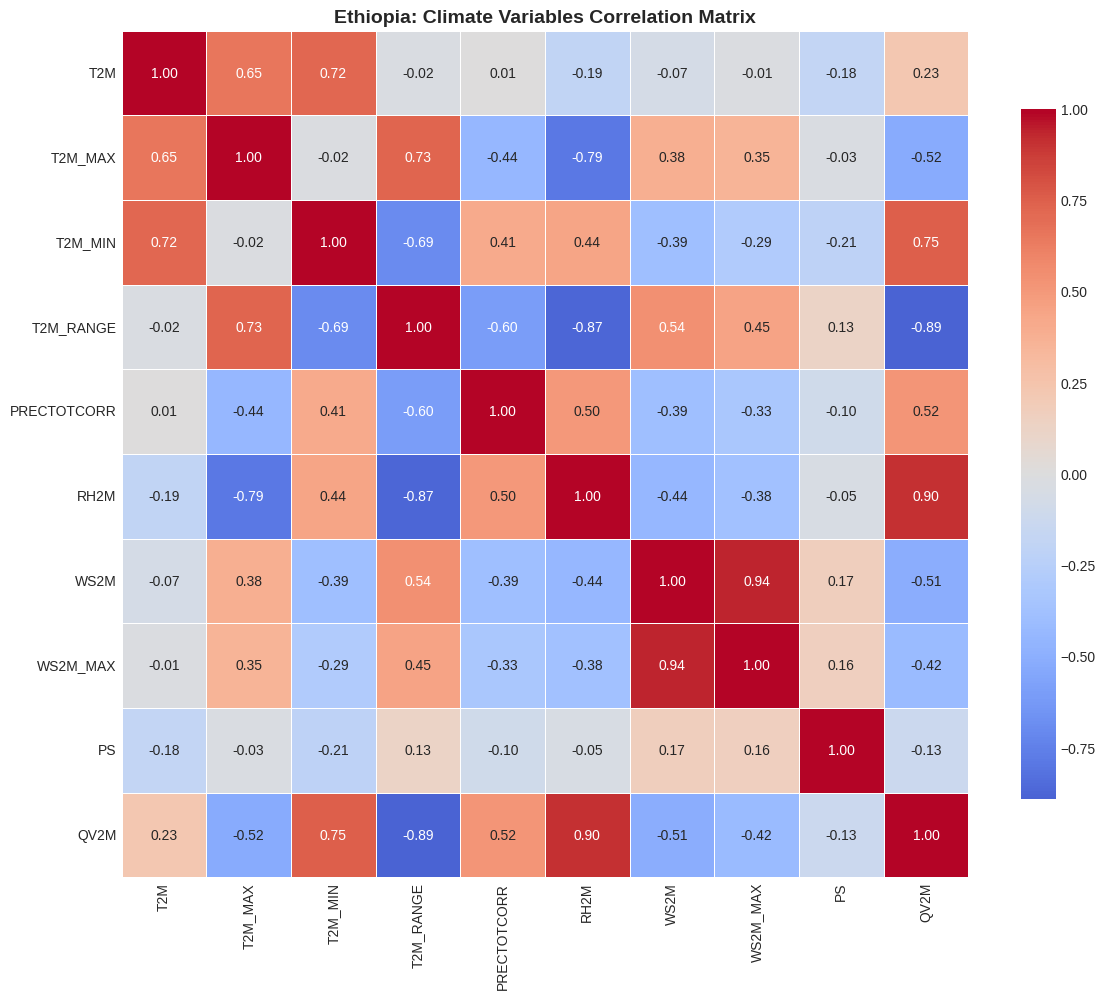


🔗 TOP 3 STRONGEST CORRELATIONS:
1. WS2M ↔ WS2M_MAX: 0.94 (positive)
2. WS2M_MAX ↔ WS2M: 0.94 (positive)
3. QV2M ↔ RH2M: 0.90 (positive)


In [ ]:
# Select numeric columns for correlation
numeric_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 
                'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']

# Filter to columns that exist
existing_cols = [col for col in numeric_cols if col in df.columns]

# Calculate correlation matrix
corr_matrix = df[existing_cols].corr()

# Create heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=0.5, 
            cbar_kws={"shrink": 0.8})

plt.title('Ethiopia: Climate Variables Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Find top 3 strongest correlations (excluding self-correlations)
corr_pairs = corr_matrix.unstack()
corr_pairs = corr_pairs[corr_pairs < 0.999]  # type: ignore # Remove self-correlations
strongest_corr = corr_pairs.abs().sort_values(ascending=False).head(6)  # type: ignore # Top 6 (3 positive + 3 negative)

print("\n🔗 TOP 3 STRONGEST CORRELATIONS:")
print("=" * 50)
count = 1
for pair in strongest_corr.index[:6]:
    if count > 3:
        break
    var1, var2 = pair
    corr_value = corr_matrix.loc[var1, var2]
    direction = "positive" if corr_value > 0 else "negative" # type: ignore
    print(f"{count}. {var1} ↔ {var2}: {corr_value:.2f} ({direction})")
    count += 1